# Bank note authentication model


In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BankNoteAuthentication.csv to BankNoteAuthentication (1).csv


In [ ]:
df = pd.read_csv("BankNoteAuthentication.csv")
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
#Data Cleaning
df.duplicated().sum()

np.int64(24)

In [ ]:
df[df.duplicated()]

,variance,skewness,curtosis,entropy,class
47,-0.7869,9.5663,-3.7867,-7.5034,0
139,-0.2062,9.2207,-3.7044,-6.8103,0
190,0.9297,-3.7971,4.6429,-0.2957,0
195,-1.8584,7.8860,-1.6643,-1.8384,0
226,0.5706,-0.0248,1.2421,-0.5621,0
268,0.9297,-3.7971,4.6429,-0.2957,0
284,-1.3000,10.2678,-2.9530,-5.8638,0
300,0.3292,-4.4552,4.5718,-0.9888,0
315,0.3292,-4.4552,4.5718,-0.9888,0
320,0.5195,-3.2633,3.0895,-0.9849,0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [ ]:
df.dtypes

,0
variance,float64
skewness,float64
curtosis,float64
entropy,float64
class,int64


In [ ]:
df["class"].value_counts()

,count
class,
0,738
1,610


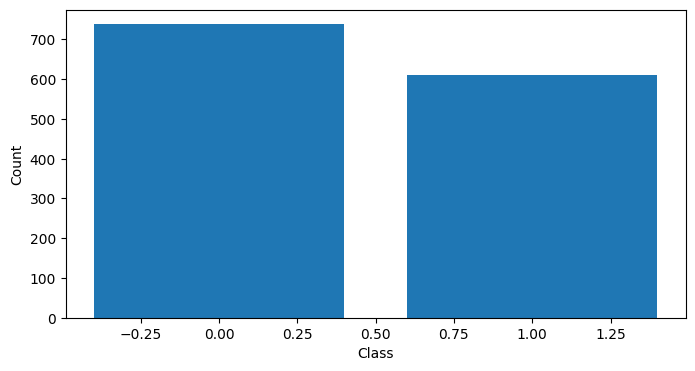

In [ ]:
#visualization check
plt.figure(figsize=(8,4))
plt.bar(df["class"].unique(), df["class"].value_counts())
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
df.describe()



,variance,skewness,curtosis,entropy,class
count,1348.000000,1348.000000,1348.000000,1348.000000,1348.000000
mean,0.445785,1.909039,1.413578,-1.168712,0.452522
std,2.862906,5.868600,4.328365,2.085877,0.497925
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.786650,-1.627000,-1.545600,-2.393100,0.000000
50%,0.518735,2.334150,0.605495,-0.578890,0.000000
75%,2.853250,6.796025,3.199800,0.403863,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
#Feature and target
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
#Cross Validation
from sklearn.model_selection import train_test_split
#sliptting into tran and test set
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#sliptting train set into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [ ]:
#Feature Scaling
#prevents data leakage, only on training data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

In [ ]:
#Train Logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#Validate model using the validation set
from sklearn.metrics import accuracy_score
val_pred = model.predict(X_val)
accuracy_score(y_val, val_pred)

0.9953703703703703

In [ ]:
#cross validation on the training set

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_full,
    y_train_full,
    cv =5,
    scoring = "accuracy"
)


In [ ]:
print(scores)
print("mean accuracy:", scores.mean())

[0.99537037 0.99537037 0.99537037 0.99069767 1.        ]
mean accuracy: 0.9953617571059432


In [ ]:
#model prediction

model_pred = model.predict(X_test)
accuracy_score(y_test, model_pred)

0.9851851851851852